# Calculating % of cells removed by various filters per metric

In [9]:
#load in data
import scanpy as sc
from pathlib import Path

reps = {}

raw_data_path = Path(r"D:\Dom\Psoriasis project\4th year data\Second Round Data\Xenium outputs - second round\Resegmented Xenium Outputs\raw_adatas")

for file in raw_data_path.glob("*h5ad"):
    reps[file.stem.removesuffix('raw_adata')] = sc.read_h5ad(file) 

len(reps)

30

In [10]:
#calculate QC metrics
for adata in reps.values():
    sc.pp.calculate_qc_metrics(adata, inplace=True)

In [27]:
def rename_compartments(item):
    #remove replicate information, keep compartment:
    if 'artilage' in item:  #not sure how to be case insensitive, just removing first letter
        item = 'cartilage'
    elif 'orsal' in item:
        if 'pidermis' in item:
            item = 'dorsal_epidermis'
        elif 'pidermis' not in item:
            item = 'dorsal_dermis'
    elif 'entral' in item:
        if 'pidermis' in item:
            item = 'ventral_epidermis'
        elif 'pidermis' not in item:
            item = 'ventral_dermis'
    return item

for bdata in reps.values():
    bdata.obs['compartment'] = bdata.obs['compartment'].apply(rename_compartments)
    print(bdata.obs['compartment'].unique())

['dorsal_epidermis', 'dorsal_dermis', 'cartilage', 'ventral_dermis', 'ventral_epidermis']
Categories (5, object): ['cartilage', 'dorsal_dermis', 'dorsal_epidermis', 'ventral_dermis', 'ventral_epidermis']
['dorsal_epidermis', 'dorsal_dermis', 'cartilage', 'ventral_dermis', 'ventral_epidermis']
Categories (5, object): ['cartilage', 'dorsal_epidermis', 'dorsal_dermis', 'ventral_epidermis', 'ventral_dermis']
['ventral_epidermis', 'ventral_dermis', 'cartilage', 'dorsal_dermis', 'dorsal_epidermis']
Categories (5, object): ['cartilage', 'dorsal_dermis', 'ventral_dermis', 'dorsal_epidermis', 'ventral_epidermis']
['ventral_epidermis', 'ventral_dermis', 'cartilage', 'dorsal_dermis', 'dorsal_epidermis']
Categories (5, object): ['cartilage', 'dorsal_epidermis', 'dorsal_dermis', 'ventral_epidermis', 'ventral_dermis']
['ventral_epidermis', 'ventral_dermis', 'cartilage', 'dorsal_dermis', 'dorsal_epidermis']
Categories (5, object): ['cartilage', 'dorsal_dermis', 'dorsal_epidermis', 'ventral_dermis', '

In [12]:
#filter objects by 1% smallest
import numpy as np
import pandas as pd

#size based
for name, adata in reps.items():
    total_original_cells = len(adata) 

    percentile_threshold = 1 #change this to filter out more or less cells
    size_threshold = np.percentile(adata.obs['cell_area'], percentile_threshold) 

    size_mask = adata.obs['cell_area'] > size_threshold 
    num_removed_size = (~size_mask).sum() #no. cells removed

    adata = adata[size_mask].copy()

    print(f'Removed {num_removed_size/total_original_cells *100:.2f}% of cells based on size requirements')

Removed 1.03% of cells based on size requirements
Removed 1.00% of cells based on size requirements
Removed 1.00% of cells based on size requirements
Removed 1.01% of cells based on size requirements
Removed 1.00% of cells based on size requirements
Removed 1.02% of cells based on size requirements
Removed 1.01% of cells based on size requirements
Removed 1.00% of cells based on size requirements
Removed 1.00% of cells based on size requirements
Removed 1.00% of cells based on size requirements
Removed 1.01% of cells based on size requirements
Removed 1.00% of cells based on size requirements
Removed 1.00% of cells based on size requirements
Removed 1.00% of cells based on size requirements
Removed 1.00% of cells based on size requirements
Removed 1.02% of cells based on size requirements
Removed 1.00% of cells based on size requirements
Removed 1.01% of cells based on size requirements
Removed 1.01% of cells based on size requirements
Removed 1.02% of cells based on size requirements


In [51]:
test = reps['Ctrl_F1'].copy()
adata.obs.value_counts('compartment')

compartment
ventral_epidermis    3368
dorsal_dermis        3152
ventral_dermis       2954
dorsal_epidermis     2801
cartilage             845
Name: count, dtype: int64

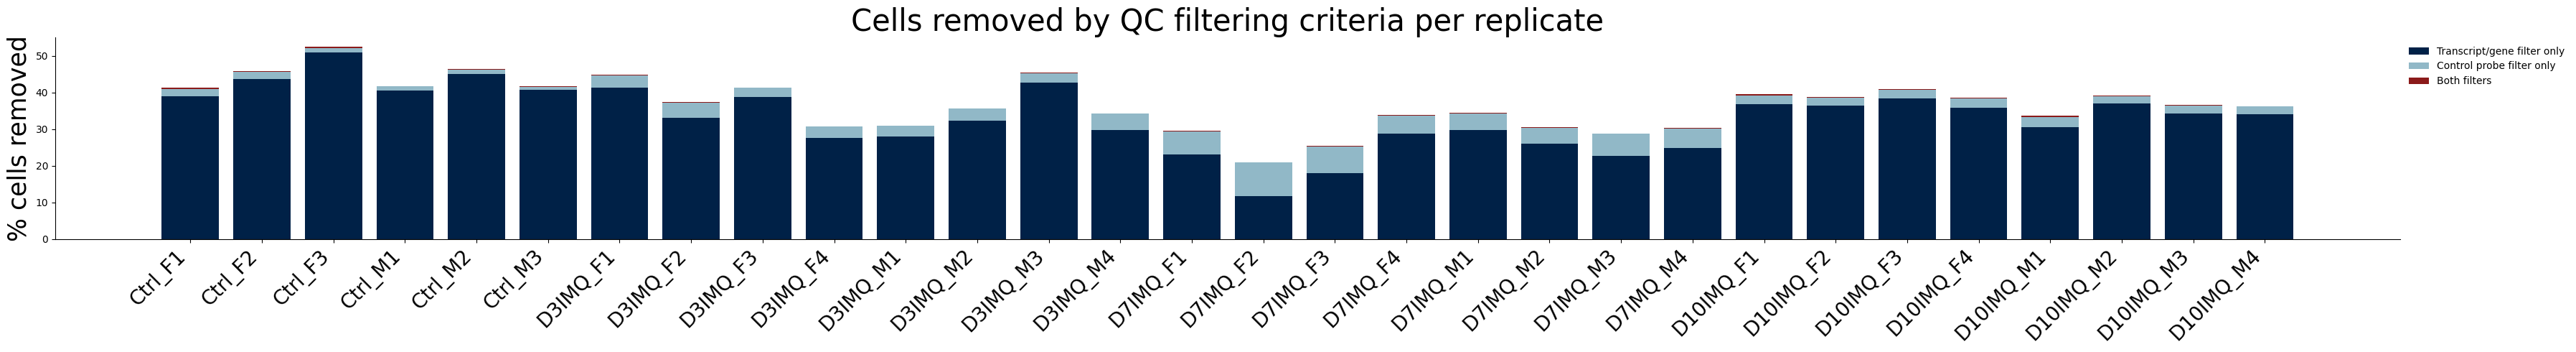

In [39]:
import matplotlib.pyplot as plt
import numpy as np
import re

rep_data = {}
for name, adata in reps.items():
    total = len(adata)

    t_mask = (
        (adata.obs['transcript_counts'] < 10) | (adata.obs['n_genes_by_counts'] < 10)
    ) & (
        (adata.obs['control_probe_counts'] == 0) &
        (adata.obs['genomic_control_counts'] == 0) &
        (adata.obs['control_codeword_counts'] == 0) &
        (adata.obs['unassigned_codeword_counts'] == 0)
    )

    c_mask = (
        (adata.obs['transcript_counts'] > 10) & (adata.obs['n_genes_by_counts'] > 10)
    ) & (
        (adata.obs['control_probe_counts'] > 0) |
        (adata.obs['genomic_control_counts'] > 0) |
        (adata.obs['control_codeword_counts'] > 0) |
        (adata.obs['unassigned_codeword_counts'] > 0)
    )

    b_mask = (
        (adata.obs['transcript_counts'] < 10) | (adata.obs['n_genes_by_counts'] < 10)
    ) & (
        (adata.obs['control_probe_counts'] > 0) |
        (adata.obs['genomic_control_counts'] > 0) |
        (adata.obs['control_codeword_counts'] > 0) |
        (adata.obs['unassigned_codeword_counts'] > 0)
    )

    rep_data[name] = {
        'transcript': t_mask.sum() / total * 100,
        'control':    c_mask.sum() / total * 100,
        'both':       b_mask.sum() / total * 100,
    }

# --- plot ---
def sort_key(name):
    if 'Ctrl' in name:
        return (0, name)
    match = re.search(r'D(\d+)', name)
    return (int(match.group(1)), name) if match else (999, name)

labels = sorted(rep_data.keys(), key=sort_key)
transcript  = [rep_data[k]['transcript'] for k in labels]
control     = [rep_data[k]['control']    for k in labels]
both        = [rep_data[k]['both']       for k in labels]

oxford_blue   = '#002147'
dark_red      = '#8B1A1A'
cambridge_blue = '#91B8C7'

x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(max(5, len(labels) * 1.2), 5))

b1 = ax.bar(x, transcript, color=oxford_blue,    label='Transcript/gene filter only')
b2 = ax.bar(x, control,    color=cambridge_blue,        label='Control probe filter only', bottom=transcript)
b3 = ax.bar(x, both,       color=dark_red,  label='Both filters',
            bottom=[t + c for t, c in zip(transcript, control)])

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize = 20)
ax.set_ylabel('% cells removed', fontsize = 25)
ax.set_title('Cells removed by QC filtering criteria per replicate', fontsize = 30)
ax.legend(frameon=False, bbox_to_anchor=(1, 1), loc='upper left')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

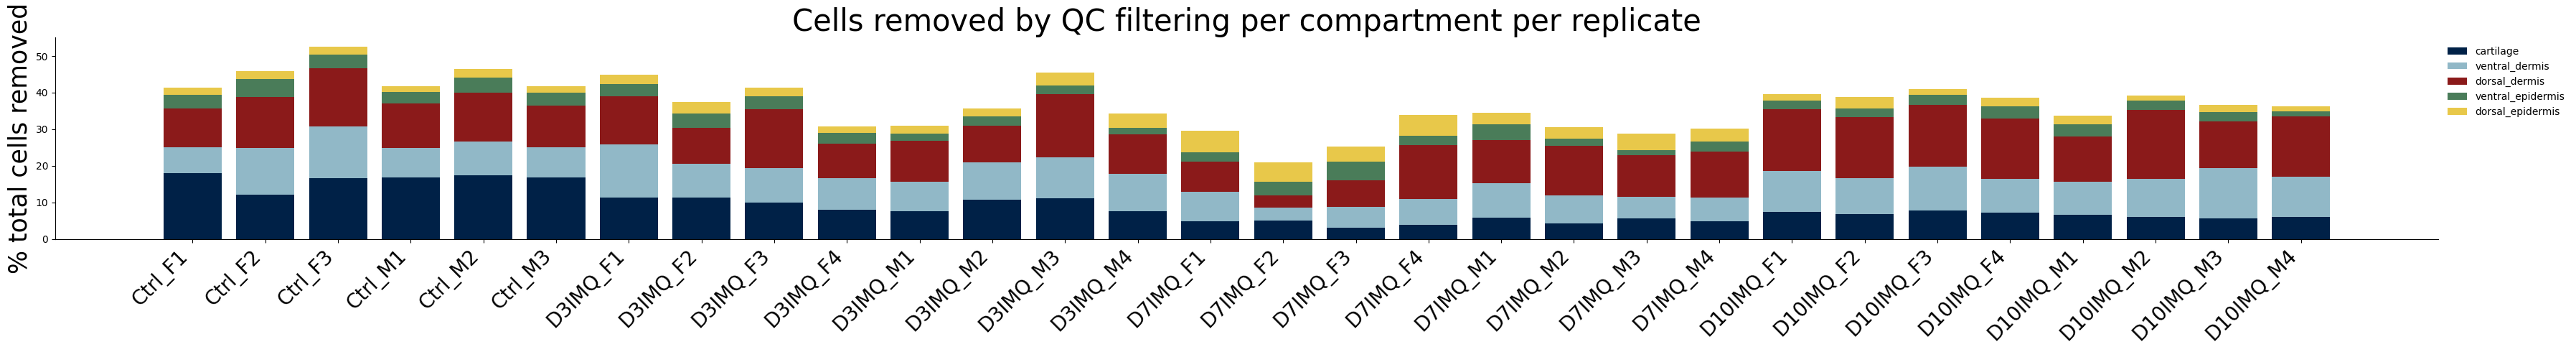

In [58]:
import matplotlib.pyplot as plt
import numpy as np
import re

compartment_order = ['cartilage', 'ventral_dermis', 'dorsal_dermis','ventral_epidermis', 'dorsal_epidermis']
compartment_colors = ['#002147', '#91B8C7', '#8B1A1A', '#4A7C59', '#E8C84A']  # adjust to taste

rep_compartment_data = {}
for name, adata in reps.items():
    total = len(adata)

    removed_mask = (
        (adata.obs['transcript_counts'] < 10) | (adata.obs['n_genes_by_counts'] < 10) |
        (adata.obs['control_probe_counts'] > 0) |
        (adata.obs['genomic_control_counts'] > 0) |
        (adata.obs['control_codeword_counts'] > 0) |
        (adata.obs['unassigned_codeword_counts'] > 0)
    )

    removed_obs = adata.obs[removed_mask]

    rep_compartment_data[name] = {}
    for comp in compartment_order:
        n_removed = (removed_obs['compartment'] == comp).sum()
        rep_compartment_data[name][comp] = n_removed / total * 100

# --- plot ---
def sort_key(name):
    if 'Ctrl' in name:
        return (0, name)
    match = re.search(r'D(\d+)', name)
    return (int(match.group(1)), name) if match else (999, name)

labels = sorted(rep_compartment_data.keys(), key=sort_key)
x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(max(5, len(labels) * 1.2), 5))

bottoms = np.zeros(len(labels))
for comp, color in zip(compartment_order, compartment_colors):
    vals = np.array([rep_compartment_data[k][comp] for k in labels])
    ax.bar(x, vals, bottom=bottoms, color=color, label=comp, width = 0.8)
    bottoms += vals

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=20)
ax.set_ylabel('% total cells removed', fontsize=25)
ax.set_title('Cells removed by QC filtering per compartment per replicate', fontsize=30)
ax.legend(frameon=False, bbox_to_anchor=(1, 1), loc='upper left')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

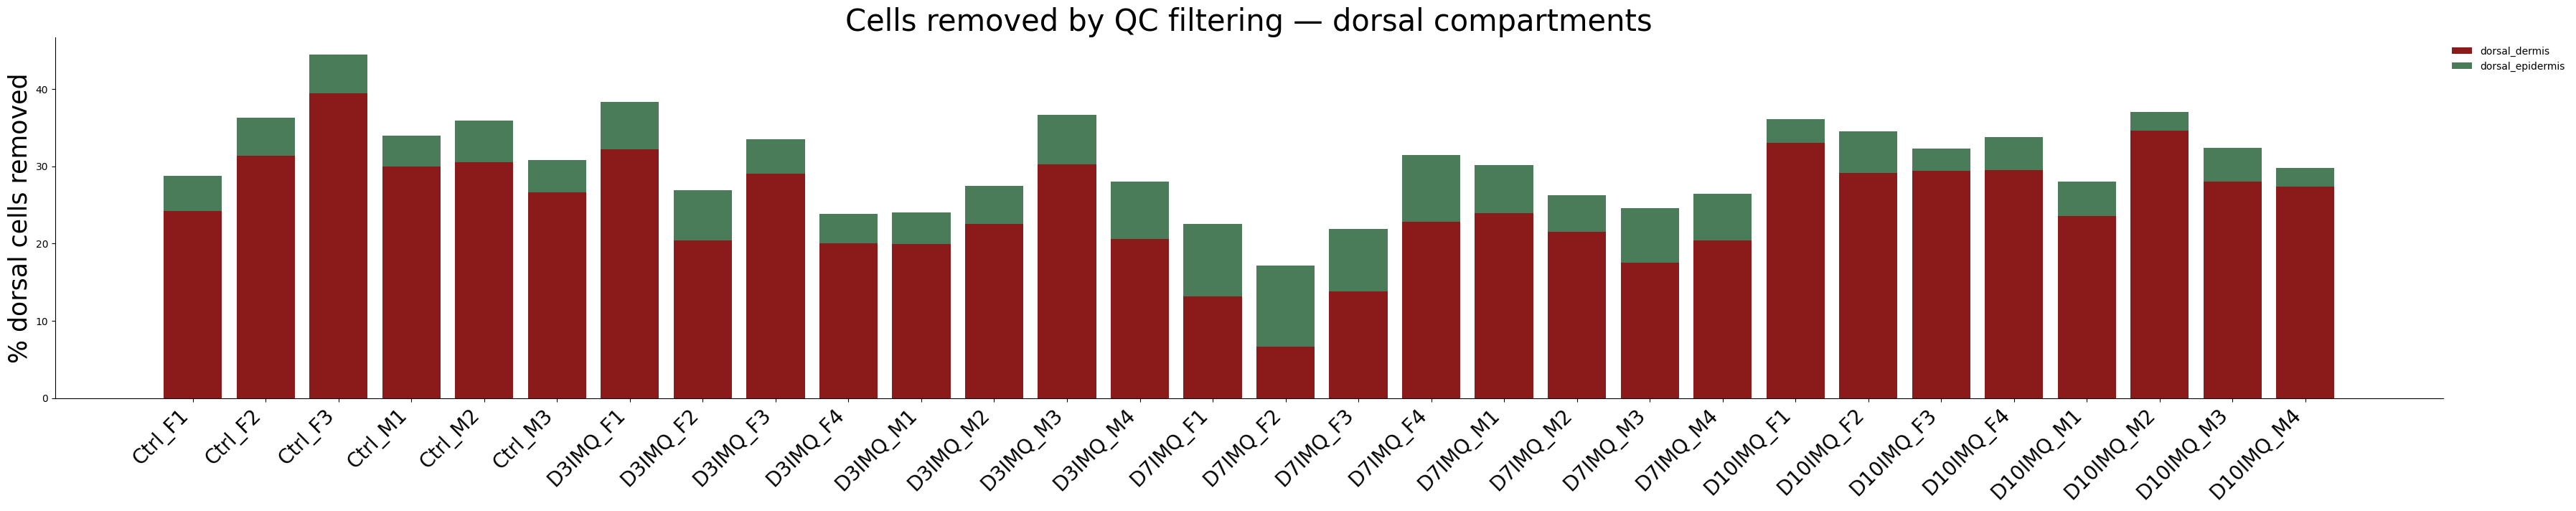

In [63]:
#plotting QC for the dorsal side only

import matplotlib.pyplot as plt
import numpy as np
import re

compartment_order = ['cartilage', 'ventral_dermis', 'dorsal_dermis','ventral_epidermis', 'dorsal_epidermis']
compartment_colors = ['#002147', '#91B8C7', '#8B1A1A', '#4A7C59', '#E8C84A']  # adjust to taste
dorsal_order = ['dorsal_dermis', 'dorsal_epidermis']
dorsal_colors = ['#8B1A1A', '#4A7C59']

rep_compartment_data = {}
for name, adata in reps.items():
    dorsal_mask = adata.obs['compartment'].isin(dorsal_order)
    dorsal_total = dorsal_mask.sum()

    removed_mask = (
        (adata.obs['transcript_counts'] < 10) | (adata.obs['n_genes_by_counts'] < 10) |
        (adata.obs['control_probe_counts'] > 0) |
        (adata.obs['genomic_control_counts'] > 0) |
        (adata.obs['control_codeword_counts'] > 0) |
        (adata.obs['unassigned_codeword_counts'] > 0)
    )

    removed_obs = adata.obs[removed_mask & dorsal_mask]

    rep_compartment_data[name] = {}
    for comp in dorsal_order:
        n_removed = (removed_obs['compartment'] == comp).sum()
        rep_compartment_data[name][comp] = n_removed / dorsal_total * 100

# --- plot ---
def sort_key(name):
    if 'Ctrl' in name:
        return (0, name)
    match = re.search(r'D(\d+)', name)
    return (int(match.group(1)), name) if match else (999, name)

labels = sorted(rep_compartment_data.keys(), key=sort_key)
x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(max(5, len(labels) * 1.2), 8))

bottoms = np.zeros(len(labels))
for comp, color in zip(dorsal_order, dorsal_colors):
    vals = np.array([rep_compartment_data[k][comp] for k in labels])
    ax.bar(x, vals, bottom=bottoms, color=color, label=comp, width=0.8)
    bottoms += vals

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=20)
ax.set_ylabel('% dorsal cells removed', fontsize=25)
ax.set_title('Cells removed by QC filtering — dorsal compartments', fontsize=30)
ax.legend(frameon=False, bbox_to_anchor=(1, 1), loc='upper left')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.subplots_adjust(bottom=0.3)
plt.show()

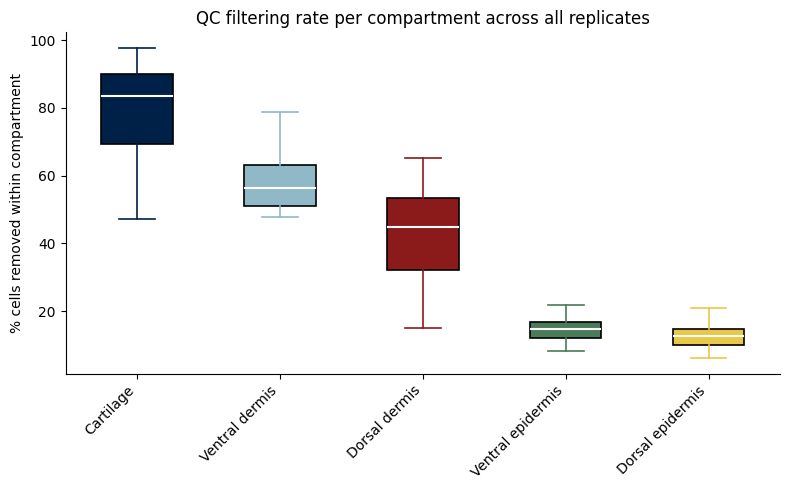

In [61]:
import matplotlib.pyplot as plt
import numpy as np

compartment_order = ['cartilage', 'ventral_dermis', 'dorsal_dermis', 'ventral_epidermis', 'dorsal_epidermis']
compartment_colors = ['#002147', '#91B8C7', '#8B1A1A', '#4A7C59', '#E8C84A']

comp_data = {comp: [] for comp in compartment_order}

for name, adata in reps.items():
    removed_mask = (
        (adata.obs['transcript_counts'] < 10) | (adata.obs['n_genes_by_counts'] < 10) |
        (adata.obs['control_probe_counts'] > 0) |
        (adata.obs['genomic_control_counts'] > 0) |
        (adata.obs['control_codeword_counts'] > 0) |
        (adata.obs['unassigned_codeword_counts'] > 0)
    )
    removed_obs = adata.obs[removed_mask]

    for comp in compartment_order:
        comp_total = (adata.obs['compartment'] == comp).sum()
        n_removed = (removed_obs['compartment'] == comp).sum()
        comp_data[comp].append(n_removed / comp_total * 100)

# --- plot ---
fig, ax = plt.subplots(figsize=(8, 5))

data = [comp_data[comp] for comp in compartment_order]

bp = ax.boxplot(data, patch_artist=True,
                medianprops=dict(linewidth=1.5),
                whiskerprops=dict(linewidth=1.2),
                capprops=dict(linewidth=1.2),
                boxprops=dict(linewidth=1.2),
                showfliers=False)
for patch, color in zip(bp['boxes'], compartment_colors):
    patch.set_facecolor(color)

for i, color in enumerate(compartment_colors):
    for element in ['whiskers', 'caps']:
        bp[element][i*2].set_color(color)
        bp[element][i*2+1].set_color(color)
    bp['medians'][i].set_color('white')

# for i, (comp, color, pos) in enumerate(zip(compartment_order, compartment_colors, range(1, len(compartment_order) + 1))):
#     for element in ['medians', 'whiskers', 'caps', 'boxes']:
#         for item in bp[element][i*2:i*2+2] if element != 'medians' else [bp[element][i]]:
#             item.set_color(color)

#     jitter = np.random.uniform(-0.1, 0.1, size=len(comp_data[comp]))
#     ax.scatter(pos + jitter, comp_data[comp],
#                facecolors='#0D0C0C', edgecolors='#0D0C0C', alpha=1, s=25, zorder=3)

ax.set_xticks(range(1, len(compartment_order) + 1))

label_names = ['Cartilage', 'Ventral dermis', 'Dorsal dermis', 'Ventral epidermis', 'Dorsal epidermis']

ax.set_xticklabels(label_names, rotation=45, ha='right')
ax.set_ylabel('% cells removed within compartment')
ax.set_title('QC filtering rate per compartment across all replicates')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

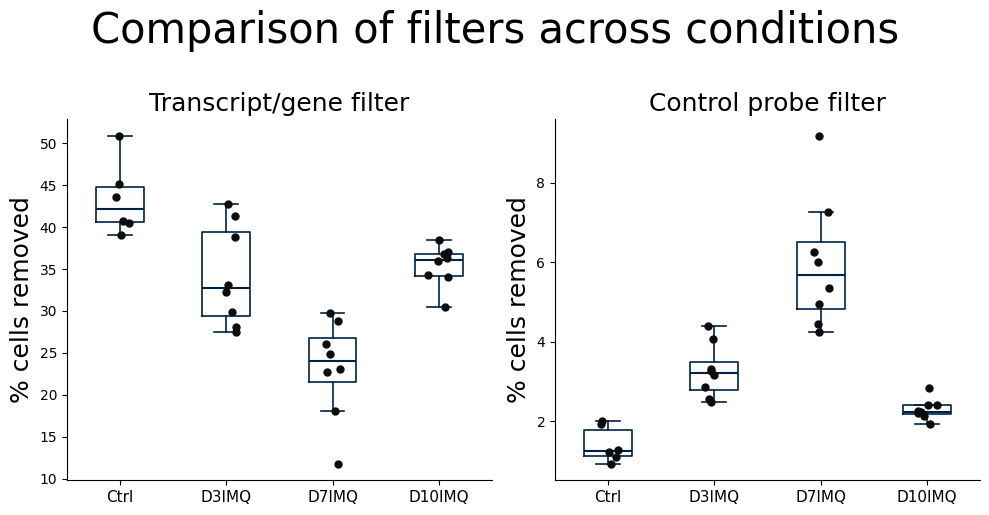

In [ ]:
#2 boxplots. (a) %cells removed by transcript/gene requirements across conditions
#(b) %cells removed by control probe requirements across conditions

import re
import matplotlib.pyplot as plt
import numpy as np

# --- organise data by condition ---
conditions_order = ['Ctrl', 'D3IMQ', 'D7IMQ', 'D10IMQ']

grouped = {cond: {'transcript': [], 'control': []} for cond in conditions_order}

for name, vals in rep_data.items():
    for cond in conditions_order:
        if cond in name:
            grouped[cond]['transcript'].append(vals['transcript'])
            grouped[cond]['control'].append(vals['control'])
            break

# --- plot ---
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

titles  = ['Transcript/gene filter', 'Control probe filter']
metrics = ['transcript', 'control']

for ax, metric, title in zip(axes, metrics, titles):
    data = [grouped[cond][metric] for cond in conditions_order]

    bp = ax.boxplot(data, patch_artist=False,
                    medianprops=dict(color='#002147', linewidth=1.5),
                    whiskerprops=dict(color='#002147', linewidth=1.2),
                    capprops=dict(color='#002147', linewidth=1.2),
                    boxprops=dict(color='#002147', linewidth=1.2),
                    showfliers=False)

    for i, (cond_data, pos) in enumerate(zip(data, range(1, len(conditions_order) + 1))):
        jitter = np.random.uniform(-0.1, 0.1, size=len(cond_data))
        ax.scatter(pos + jitter, cond_data,
                facecolors='#0D0C0C', edgecolors='#0D0C0C', alpha=1, s=25, zorder=3)

    ax.set_xticks(range(1, len(conditions_order) + 1))
    ax.set_xticklabels(conditions_order, fontsize = 11)
    ax.set_ylabel('% cells removed', fontsize = 18)
    ax.set_title(title, fontsize = 18)
    ax.spines[['top', 'right']].set_visible(False)


fig.suptitle('Comparison of filters across conditions', fontsize=30, y=1.02)
plt.tight_layout()
plt.show()